# Exploratory Data Analysis — Kickstarter Campaigns
**Group_ID-13** · Words That Fund: Linguistic Patterns in Crowdfunding Campaign Success

### Outline
1. Setup & Data Loading
2. Dataset Overview
3. Missing Values & Data Quality
4. Category Analysis
5. Funding Goal Distribution
6. Pledged Amount Distribution
7. Goal vs. Pledged (by outcome)
8. Description Length Analysis
9. Description Length vs. Amount Funded


## 1. Setup & Data Loading

In [1]:
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# ── consistent style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (10, 4)})

BLUE, RED, PALETTE = "#477ADA", "#D65F5F", ["#4878CF", "#D65F5F"]


In [6]:
df = pd.read_csv("Kickstarter_processed (2).csv", index_col=0)

# Parse token lists
def parse_tokens(cell):
    try:
        return ast.literal_eval(cell)
    except Exception:
        return []

df["tokens"]    = df["description_processed"].apply(parse_tokens)
df["token_count"] = df["tokens"].apply(len)

# Description length in characters and words
df["desc_char_len"] = df["description"].str.len()
df["desc_word_len"] = df["description"].str.split().str.len()

# Human-readable outcome label
df["outcome"] = df["status"].map({1: "Successful", 0: "Failed"})

print(f"Shape: {df.shape}")
#df.head(3)


Shape: (7354, 20)


## 2. Dataset Overview

In [28]:
print("=== Column Types ===")
print(df.dtypes)
print()
print("=== Numeric Summary ===")
display(df[["pledged", "goal", "reached", "desc_char_len", "desc_word_len", "token_count"]].describe().round(2))


=== Column Types ===
url                       object
title                     object
description               object
pledged                  float64
goal                     float64
currency                  object
reached                  float64
status                     int64
description_processed     object
stemmed                   object
lemmatized                object
category                  object
tokens                    object
token_count                int64
desc_char_len              int64
desc_word_len              int64
outcome                   object
dtype: object

=== Numeric Summary ===


,pledged,goal,reached,desc_char_len,desc_word_len,token_count
count,7354.00,7354.00,7354.00,7354.00,7354.00,7354.00
mean,47353.51,24875.76,235.72,5821.51,976.02,572.83
std,238421.53,43025.12,1136.09,4601.52,763.59,463.33
min,66.00,5001.00,0.20,802.00,101.00,67.00
25%,3152.50,9400.00,15.99,2597.00,442.00,251.00
50%,10397.50,13000.00,102.69,4500.50,755.00,437.00
75%,24396.25,25000.00,125.82,7621.00,1278.75,749.00
max,8243797.00,1000000.00,41290.95,35273.00,6237.00,4029.00


## 3. Missing Values & Data Quality

In [29]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({"missing_count": missing, "missing_%": missing_pct})
quality = quality[quality["missing_count"] > 0]

if quality.empty:
    print("✓ No missing values found in any column.")
else:
    display(quality)

# Duplicates
dupes = df.duplicated(subset=["description"]).sum()
print(f"Duplicate descriptions: {dupes}")

# Currency
print(f"Currencies present: {df['currency'].value_counts().to_dict()}")


,missing_count,missing_%
title,50,0.68


Duplicate descriptions: 1252
Currencies present: {'USD': 7354}


## 4. Category Analysis

The five major categories chosen for this analysis with most to least campaigns were as follows: *Film & Video*, *Technology*, *Games*, *Publishing* and *Music*. From the campaigns we selected at random from each category, the success rate is highest for the *Music* category and the least for the *Film & Video* category. 

*Music*, *Games* and *Publishing* are the three categories that cross the 50% success rate threshold while the other two fail to do so with a success rate between 42-45% for *Film and Video* and *Technology*.

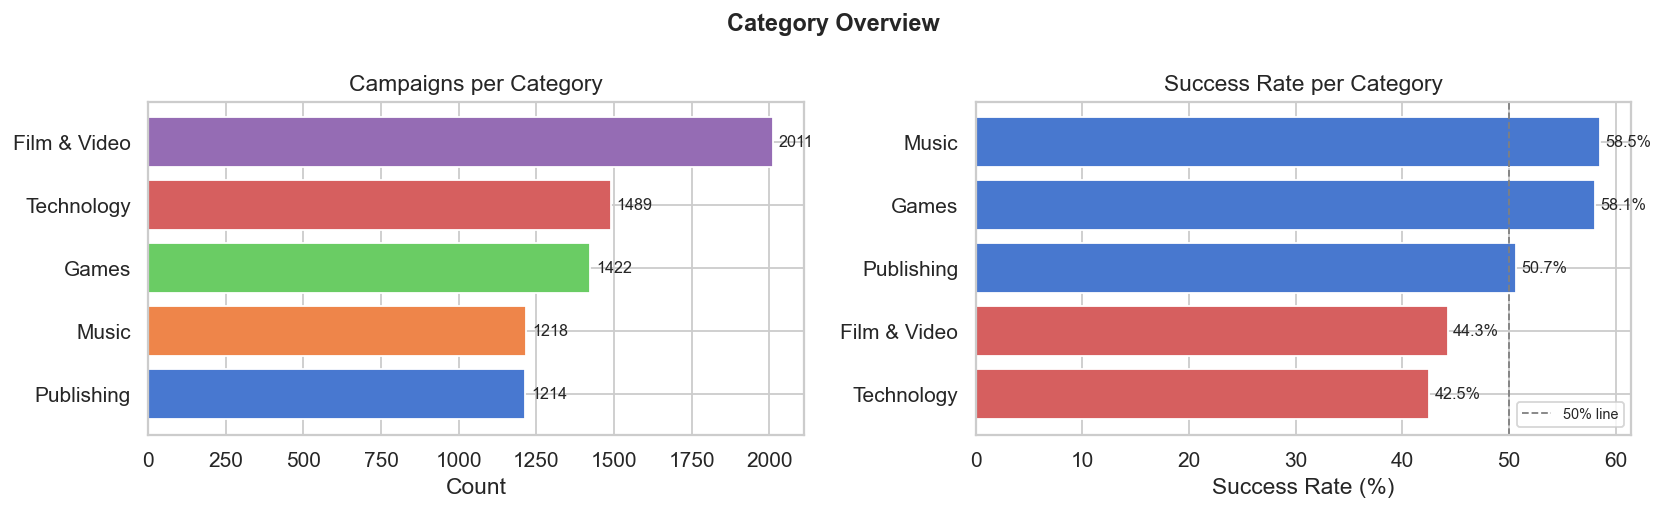

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Campaign count per category
cat_counts = df["category"].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1],
             color=sns.color_palette("muted", len(cat_counts)), edgecolor="white")
for i, v in enumerate(cat_counts.values[::-1]):
    axes[0].text(v + 20, i, str(v), va="center", fontsize=9)
axes[0].set_title("Campaigns per Category")
axes[0].set_xlabel("Count")

# Success rate per category
sr = df.groupby("category")["status"].mean().sort_values() * 100
colors = [BLUE if v >= 50 else RED for v in sr.values]
axes[1].barh(sr.index, sr.values, color=colors, edgecolor="white")
axes[1].axvline(50, color="grey", linestyle="--", linewidth=1, label="50% line")
for i, v in enumerate(sr.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
axes[1].set_title("Success Rate per Category")
axes[1].set_xlabel("Success Rate (%)")
axes[1].legend(fontsize=8)

plt.suptitle("Category Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_02_category_overview.png", bbox_inches="tight")
plt.show()


### Figure interpretation — Category Overview

The **left panel** is a horizontal bar chart showing campaign counts per category. *Film & Video* is the largest group, followed by *Technology*, *Games*, *Publishing*, and *Music*. The **right panel** reports the success rate per category. Categories are colour-coded: blue indicates a success rate at or above the 50% threshold (dashed line), red indicates below. *Music*, *Games*, and *Publishing* cross the 50% mark, while *Film & Video* and *Technology* fall in the 42–45% range. The contrast between volume (*Film & Video* being the largest category) and success rate (where it ranks lowest) highlights that sheer campaign quantity does not correlate with higher success probability.

## 5. Funding Goal Distribution

With a mean of $25244, the graph showcases that most of the values are centered around the $15-$30k region. By outcome, we see that the median goal for successful projects is $11,870 and for failed projects its at $15,000. This means that successful projects tend to set a lower funding goal.

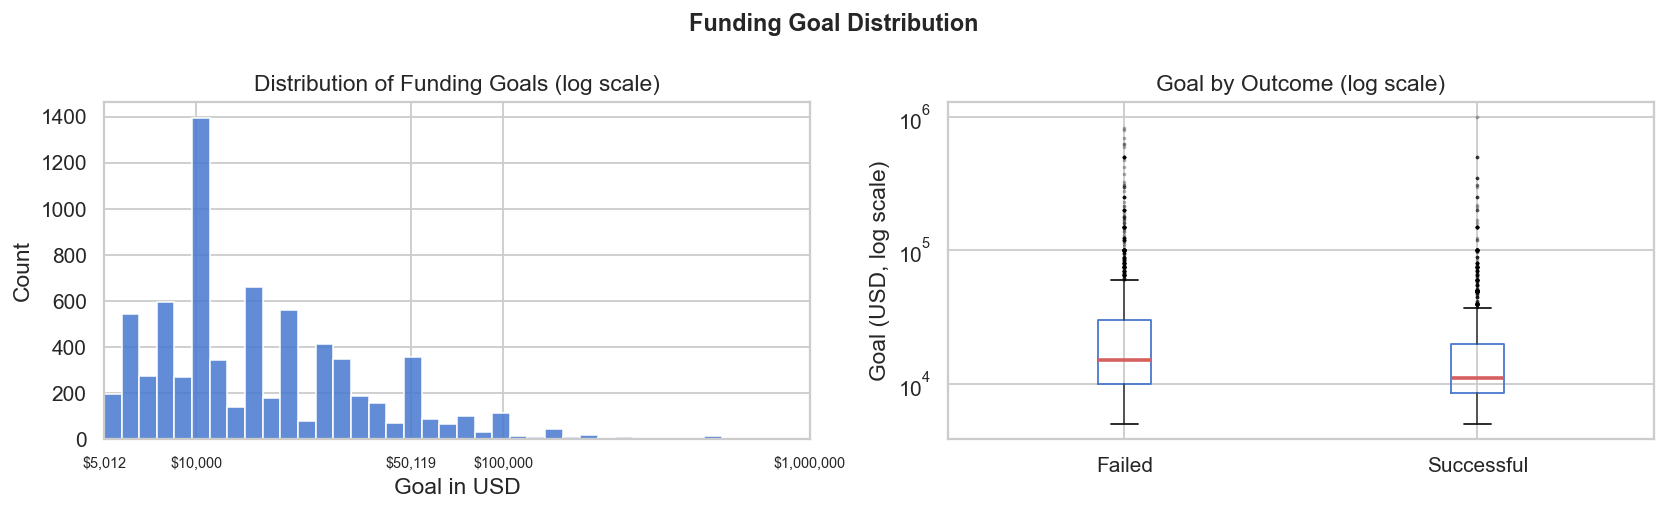

Median goal — Successful: $11,000  |  Failed: $15,000


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(np.log10(df["goal"]), bins=40, color=BLUE, edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Goal in USD")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Funding Goals (log scale)")
axes[0].margins(x=0)

xt = [3.7, 4, 4.7, 5, 6]   # ← starts at 3.7 (~$5,000) instead of 3 ($1,000)
axes[0].set_xticks(xt)
axes[0].set_xticklabels([f"${10**x:,.0f}" for x in xt], fontsize=8)
# Box plot by outcome
df.boxplot(column="goal", by="outcome", ax=axes[1],
           boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))
axes[1].set_yscale("log")
axes[1].set_title("Goal by Outcome (log scale)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Goal (USD, log scale)")
plt.suptitle("")

plt.suptitle("Funding Goal Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_04_goal_distribution.png", bbox_inches="tight")
plt.show()

print("Median goal — Successful: ${:,.0f}  |  Failed: ${:,.0f}".format(
    df[df.status==1]["goal"].median(),
    df[df.status==0]["goal"].median()
))


### Figure interpretation — Funding Goal Distribution

The **left panel** is a histogram of funding goals plotted on a log₁₀ scale. The distribution is approximately bell-shaped on the log scale, with most campaigns setting goals in the ,000–0,000 range (log ~3.7–4.7). Very few projects target amounts above M. The **right panel** is a box plot of goal by outcome (log scale). The median goal for **Successful** campaigns (~1,870) is visibly lower than for **Failed** ones (~5,000), and the interquartile ranges partially overlap. This suggests that projects with more modest, achievable financial targets have a higher likelihood of success, consistent with the known anchoring effect in crowdfunding behaviour.

## 6. Pledged Amount Distribution

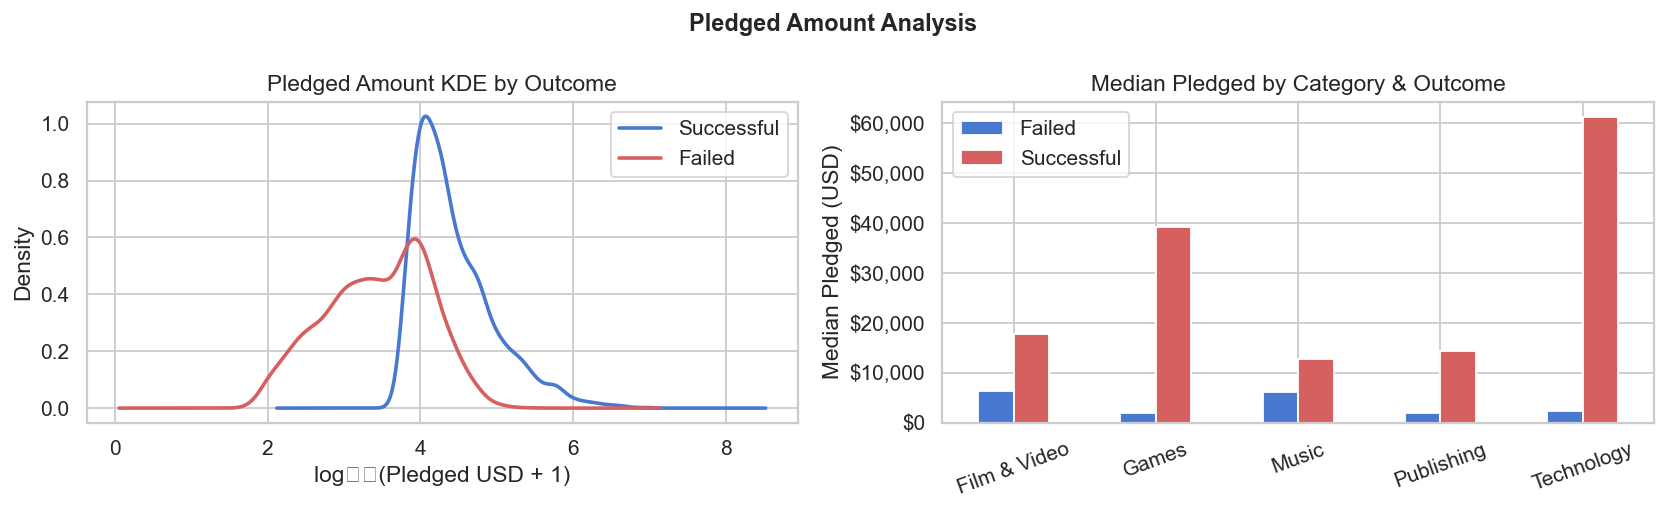

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# KDE by outcome on log scale
for label, color in zip(["Successful", "Failed"], PALETTE):
    sub = np.log10(df[df["outcome"] == label]["pledged"] + 1)
    sub.plot.kde(ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_xlabel("log₁₀(Pledged USD + 1)")
axes[0].set_title("Pledged Amount KDE by Outcome")
axes[0].legend()

# Median pledged per category
med_pledged = df.groupby(["category","outcome"])["pledged"].median().unstack()
med_pledged.plot(kind="bar", color=PALETTE, ax=axes[1], edgecolor="white")
axes[1].set_title("Median Pledged by Category & Outcome")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median Pledged (USD)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.suptitle("Pledged Amount Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_05_pledged_distribution.png", bbox_inches="tight")
plt.show()


### Figure interpretation — Pledged Amount Analysis

The **left panel** shows KDE curves of log₁₀(pledged + 1) by outcome. Successful campaigns display a broad distribution with a peak around log ~4–5 (i.e., 0k–00k), while Failed campaigns are heavily concentrated near zero, indicating that most unsuccessful projects attracted only minimal backing. The **right panel** is a grouped bar chart of median pledged amounts by category and outcome. Across all five categories, the gap between successful and failed campaigns is substantial. *Technology* and *Games* show the highest median pledged amounts among successful campaigns, whereas failed campaigns remain below ,000 median pledged regardless of category.

## 7. Goal vs. Pledged


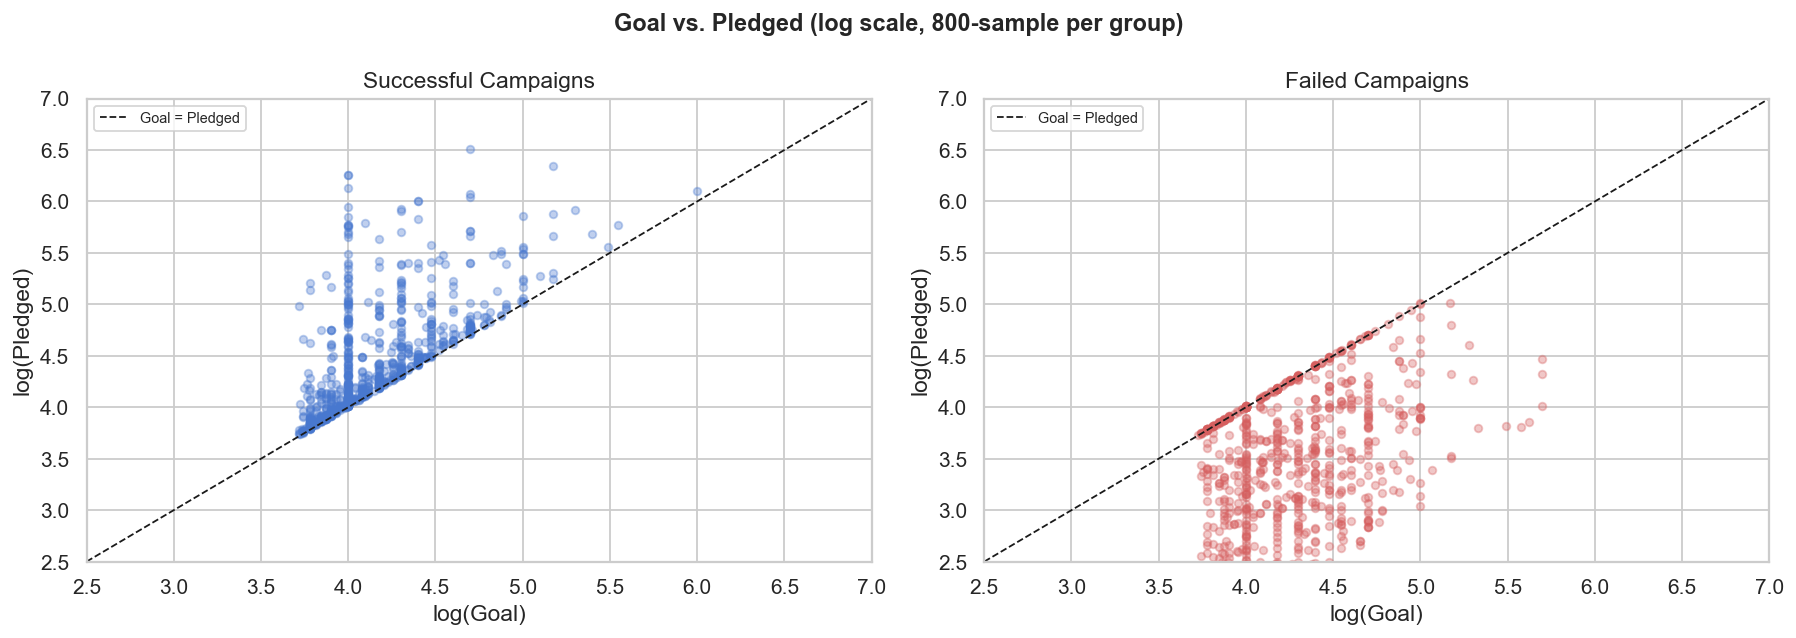

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, color) in zip(axes, zip(["Successful","Failed"], PALETTE)):
    sub = df[df["outcome"] == label].sample(min(800, len(df)), random_state=42)
    ax.scatter(np.log10(sub["goal"]+1), np.log10(sub["pledged"]+1),
               alpha=0.35, s=18, color=color)
    # identity line
    lims = [2.5, 7]
    ax.plot(lims, lims, "k--", linewidth=1, label="Goal = Pledged")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("log(Goal)")
    ax.set_ylabel("log(Pledged)")
    ax.set_title(f"{label} Campaigns")
    ax.legend(fontsize=8)

plt.suptitle("Goal vs. Pledged (log scale, 800-sample per group)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_07_goal_vs_pledged.png", bbox_inches="tight")
plt.show()


### Figure interpretation — Goal vs. Pledged Scatter Plot (log scale, 800-sample per group)

Both panels plot log₁₀(goal) on the x-axis against log₁₀(pledged) on the y-axis for a random sample of 800 campaigns per outcome group. The dashed diagonal line represents the identity line (goal = pledged). For **Successful** campaigns, points cluster tightly at or above the identity line, confirming that these projects met or exceeded their funding target. For **Failed** campaigns, the point cloud falls predominantly below the line, with many projects concentrated near the bottom of the pledged axis, reflecting negligible backer support relative to goal. The separation between the two panels provides a clear visual confirmation that the  variable is a reliable proxy for whether pledged ≥ goal.

## 8. Description Length Analysis

We measure description length two ways:
- **Character count** — total characters in the raw description
- **Word count** — whitespace-split word tokens


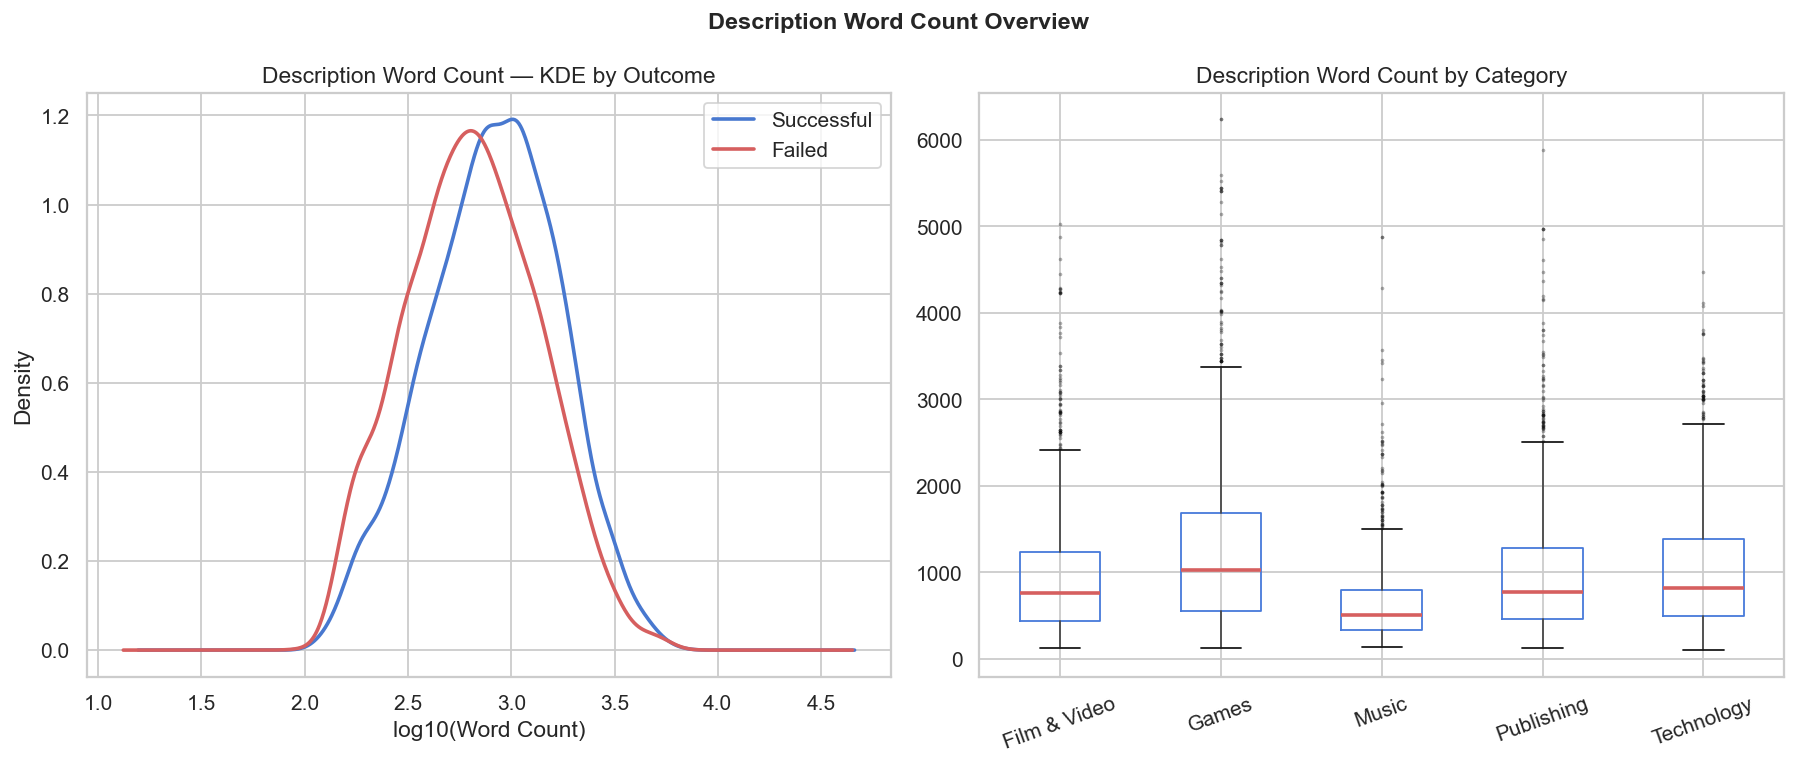


=== Description Word Count by Outcome ===


,count,mean,std,min,25%,50%,75%,max
outcome,,,,,,,,
Failed,2844.0,848.7,701.9,101.0,377.0,637.5,1083.0,5881.0
Successful,4510.0,1056.3,789.6,115.0,495.0,842.0,1385.0,6237.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

col = "desc_word_len"
label = "Word Count"

# KDE by outcome
for outcome, color in zip(["Successful", "Failed"], PALETTE):
    vals = np.log10(df[df["outcome"] == outcome][col].clip(lower=1))
    vals.plot.kde(ax=axes[0], label=outcome, color=color, linewidth=2)

axes[0].set_xlabel(f"log10({label})")
axes[0].set_title(f"Description {label} — KDE by Outcome")
axes[0].legend()

# Box plot by category
df.boxplot(column=col, by="category", ax=axes[1],
           boxprops=dict(color=BLUE),
           medianprops=dict(color=RED, linewidth=2),
           flierprops=dict(marker=".", markersize=2, alpha=0.3))

axes[1].set_title(f"Description {label} by Category")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.suptitle("Description Word Count Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== Description Word Count by Outcome ===")
display(df.groupby("outcome")["desc_word_len"].describe().round(1))

### Figure interpretation — Description Word Count Overview

The **left panel** is a KDE (kernel density estimate) of log₁₀(word count) split by outcome. The two distributions largely overlap, but the Successful curve is slightly right-shifted, indicating that successful campaigns tend to have marginally longer descriptions on average. The **right panel** is a box plot of raw word count by category. Median values are broadly comparable across the five categories (roughly 100–200 words), with *Technology* and *Film & Video* exhibiting greater spread and more upper-end outliers. The descriptive statistics table below the charts provides exact quartile values by outcome.

## 9. Description Length vs. Amount Funded

We examine whether longer campaign descriptions are associated with higher pledged amounts,
using both **scatter plots** and **binned median plots** for a cleaner signal.
Statistical tests (Pearson & Spearman correlations) are reported for each group.

There is a **modest positive** correlation between description length and amount funded overall, with a non-linear relationship that differs by category. The correlation coefficient is higher for successful projects, indicating that more elaborate descriptions were rewarded, but length alone cannot be used to determine whether a project can succeed.

*Technology* having the highest overall and failure correlation can be used to infer that backers prefer simpler and concise descriptions for this category.


In [38]:
def annotate_corr(ax, x, y, loc=(0.04, 0.93)):
    mask = np.isfinite(x) & np.isfinite(y)
    r_p, p_p = stats.pearsonr(x[mask], y[mask])
    r_s, p_s = stats.spearmanr(x[mask], y[mask])
    
    # Use parentheses to wrap the multi-line string
    txt = (
        f"Pearson r = {r_p:+.3f} (p={'<0.001' if p_p<0.001 else f'{p_p:.3f}'})\n"
        f"Spearman ρ = {r_s:+.3f} (p={'<0.001' if p_s<0.001 else f'{p_s:.3f}'})"
    )
    
    ax.text(*loc, txt, transform=ax.transAxes, fontsize=8,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))


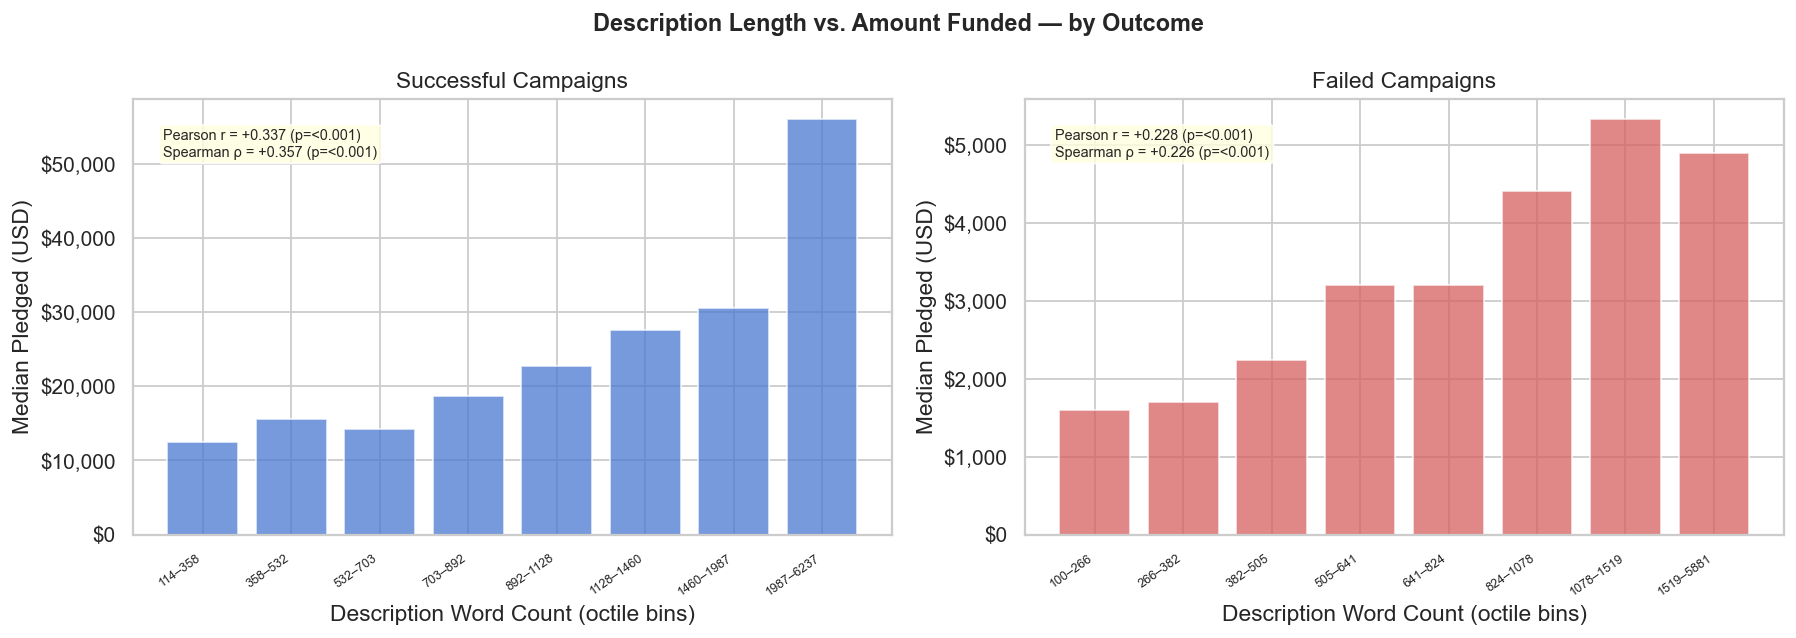

In [40]:
# ── Fig B: Same analysis split by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, outcome, color in zip(axes, ["Successful","Failed"], PALETTE):
    sub = df[df["outcome"]==outcome].copy()
    sub["word_len_bin"] = pd.qcut(sub["desc_word_len"], q=8, duplicates="drop")
    bstats = sub.groupby("word_len_bin", observed=True).agg(
        median_pledged=("pledged","median"),
        n=("pledged","count")
    ).reset_index()

    ax.bar(range(len(bstats)), bstats["median_pledged"],
           color=color, alpha=0.75, edgecolor="white")
    ax.set_xticks(range(len(bstats)))
    ax.set_xticklabels(
        [f"{int(b.left)}–{int(b.right)}" for b in bstats["word_len_bin"]],
        rotation=35, ha="right", fontsize=7
    )
    ax.set_xlabel("Description Word Count (octile bins)")
    ax.set_ylabel("Median Pledged (USD)")
    ax.set_title(f"{outcome} Campaigns")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    # correlation within this group
    annotate_corr(ax,
                  np.log10(sub["desc_word_len"].clip(lower=1).values),
                  np.log10(sub["pledged"].clip(lower=1).values))

plt.suptitle("Description Length vs. Amount Funded — by Outcome",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_10_desc_len_vs_pledged_by_outcome.png", bbox_inches="tight")
plt.show()


### Figure interpretation — Description Length vs. Amount Funded by Outcome (octile-binned bar charts)

Each panel shows the median pledged amount across eight equal-frequency bins of description word count, separately for Successful (blue) and Failed (red) campaigns. For **Successful** campaigns, median pledged increases with description length in the lower word-count bins, then levels off or becomes noisier in the upper bins, suggesting diminishing returns for very long descriptions. For **Failed** campaigns, the pattern is flatter and less consistent, indicating that description length alone does not compensate for other structural weaknesses of a campaign. Pearson r and Spearman ρ annotations (both p < 0.001) confirm a statistically significant but modest positive correlation in both groups, with a higher coefficient for Successful campaigns.

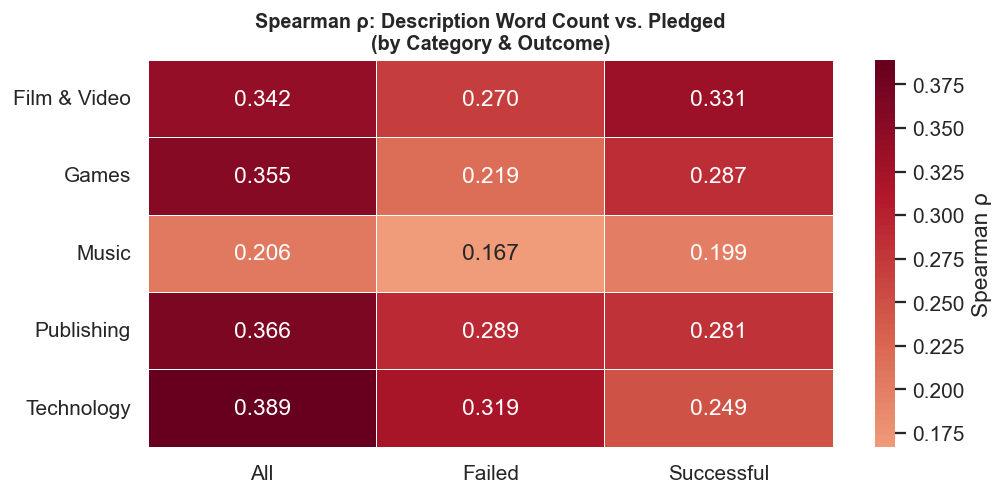


Full correlation table:


,category,group,spearman_rho,p_value
0,Film & Video,All,0.342,0.0000
1,Film & Video,Failed,0.270,0.0000
2,Film & Video,Successful,0.331,0.0000
3,Games,All,0.355,0.0000
4,Games,Failed,0.219,0.0000
5,Games,Successful,0.287,0.0000
6,Music,All,0.206,0.0000
7,Music,Failed,0.167,0.0002
8,Music,Successful,0.199,0.0000
9,Publishing,All,0.366,0.0000


In [41]:
# ── Fig C: Per-category correlation heatmap
corr_rows = []
for cat in df["category"].unique():
    for outcome in ["Successful", "Failed", "All"]:
        sub = df[df["category"]==cat] if outcome=="All" else df[(df["category"]==cat)&(df["outcome"]==outcome)]
        if len(sub) < 30:
            continue
        x = np.log10(sub["desc_word_len"].clip(lower=1))
        y = np.log10(sub["pledged"].clip(lower=1))
        r, p = stats.spearmanr(x, y)
        corr_rows.append({"category": cat, "group": outcome, "spearman_rho": round(r,3), "p_value": round(p,4)})

corr_df = pd.DataFrame(corr_rows)
pivot = corr_df.pivot(index="category", columns="group", values="spearman_rho")

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", center=0,
            cmap="RdBu_r", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Spearman ρ"})
ax.set_title("Spearman ρ: Description Word Count vs. Pledged\n(by Category & Outcome)",
             fontsize=11, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("eda_11_corr_heatmap.png", bbox_inches="tight")
plt.show()

print("\nFull correlation table:")
display(corr_df.sort_values(["category","group"]).reset_index(drop=True))


### Figure interpretation — Spearman ρ Heatmap (Description Word Count vs. Pledged, by Category & Outcome)

The heatmap reports the Spearman rank correlation between description word count and amount pledged, broken down by category (rows) and group (columns: All / Failed / Successful). Positive values (blue) indicate that longer descriptions tend to co-occur with higher pledged amounts; negative values (red) indicate the opposite. *Technology* consistently shows the highest positive ρ across all three groups, suggesting that in this category description length is more strongly associated with backer engagement. *Film & Video* and *Publishing* show weaker and more mixed correlations. The divergence between the Successful and Failed columns within the same category reveals that the relationship between description length and funding is outcome-dependent and should not be generalised across the full dataset without stratification.